# Параметрическое исследование модели SIR

Полный факторный план разделяет влияние вероятности передачи, частоты
контактов и скорости выздоровления на пик эпидемии.

SIR parameter grid: 36 combinations


R0 range: 0.357–7.0
Peak I range: 10.0–580.35


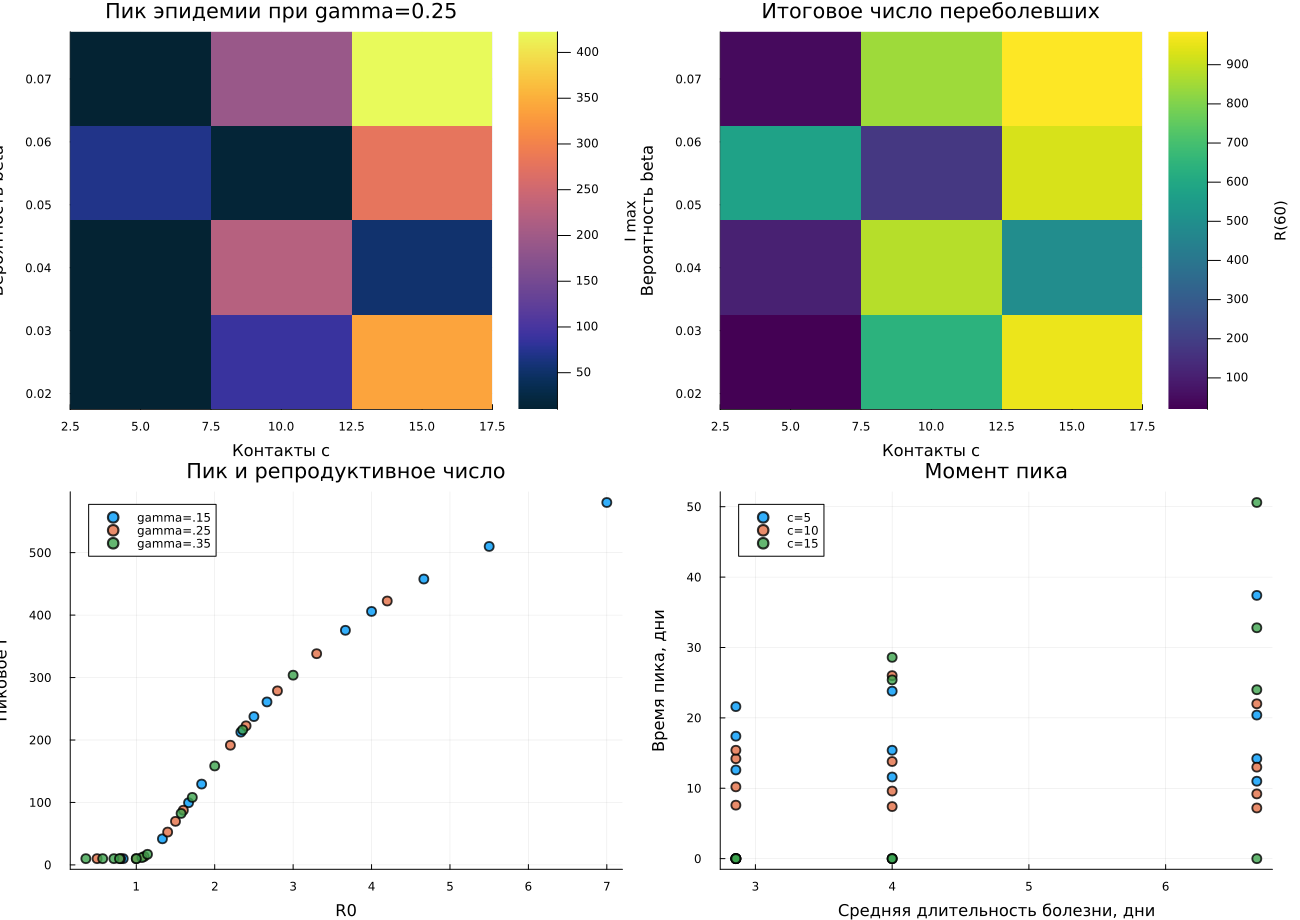

In [1]:
using DrWatson
@quickactivate "BasicModelsLab"
using BasicModelsLab.BasicModels
using CSV, DataFrames, JLD2, Plots, Statistics

script_name = "sir_ode__param"
mkpath(datadir(script_name))
mkpath(plotsdir(script_name))
gr()

betas = [0.025, 0.04, 0.055, 0.07]
contacts = [5.0, 10.0, 15.0]
gammas = [0.15, 0.25, 0.35]
u0 = [990.0, 10.0, 0.0]
tspan = (0.0, 60.0)
rows = NamedTuple[]

for beta in betas, contacts_per_day in contacts, gamma in gammas
    p = [beta, contacts_per_day, gamma]
    frame = sir_dataframe(solve_sir(; u0, p, tspan, saveat=0.2))
    peak_index = argmax(frame.I)
    push!(rows, (
        beta=beta, contacts=contacts_per_day, gamma=gamma,
        R0=beta * contacts_per_day / gamma,
        peak_infected=frame.I[peak_index], peak_time=frame.t[peak_index],
        final_recovered=frame.R[end], susceptible_end=frame.S[end],
        population_error=maximum(abs.(frame.N .- sum(u0))),
    ))
end

scan = DataFrame(rows)
CSV.write(datadir(script_name, "sir_parameter_grid.csv"), scan)
@save datadir(script_name, "sir_parameter_grid.jld2") betas contacts gammas scan

println("SIR parameter grid: $(nrow(scan)) combinations")
println("R0 range: $(round(minimum(scan.R0), digits=3))–$(round(maximum(scan.R0), digits=3))")
println("Peak I range: $(round(minimum(scan.peak_infected), digits=2))–$(round(maximum(scan.peak_infected), digits=2))")

reference_gamma = 0.25
slice = filter(:gamma => ==(reference_gamma), scan)
peak_heat = reshape(slice.peak_infected, length(betas), length(contacts))
final_heat = reshape(slice.final_recovered, length(betas), length(contacts))

peak_plot = heatmap(contacts, betas, peak_heat;
    xlabel="Контакты c", ylabel="Вероятность beta", colorbar_title="I max",
    title="Пик эпидемии при gamma=$(reference_gamma)", c=:thermal, size=(820, 520))
final_plot = heatmap(contacts, betas, final_heat;
    xlabel="Контакты c", ylabel="Вероятность beta", colorbar_title="R(60)",
    title="Итоговое число переболевших", c=:viridis, size=(820, 520))

r0_plot = scatter(scan.R0, scan.peak_infected; group=string.(scan.gamma),
    xlabel="R0", ylabel="Пиковое I", title="Пик и репродуктивное число",
    label=["gamma=.15" "gamma=.25" "gamma=.35"], ms=5, alpha=.8, size=(820, 520))

duration_plot = scatter(1 ./ scan.gamma, scan.peak_time; group=string.(scan.contacts),
    xlabel="Средняя длительность болезни, дни", ylabel="Время пика, дни",
    title="Момент пика", ms=5, alpha=.8, size=(820, 520),
    label=["c=5" "c=10" "c=15"])

panel = plot(peak_plot, final_plot, r0_plot, duration_plot; layout=(2, 2), size=(1300, 920))
savefig(peak_plot, plotsdir(script_name, "sir_peak_heatmap.png"))
savefig(final_plot, plotsdir(script_name, "sir_final_heatmap.png"))
savefig(r0_plot, plotsdir(script_name, "sir_peak_vs_R0.png"))
savefig(duration_plot, plotsdir(script_name, "sir_peak_timing.png"))
savefig(panel, plotsdir(script_name, "sir_parameter_panel.png"))

display(panel)